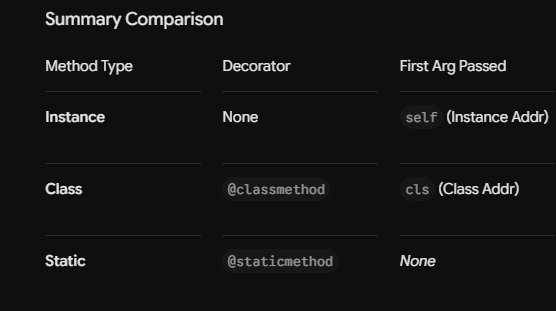
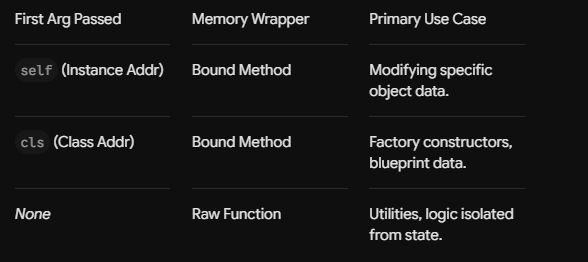

, not every method inside a class definition is a "class method." In Python terminology, the standard functions you write inside a class (like def speak(self):) are called Instance Methods, because their entire purpose is to operate on a specific instance object using the self pointer.

@classmethod and @staticmethod are specialized tools that change exactly what pointers the C-engine passes into the function.

Here is the complete breakdown of how they work, why they exist, and exactly how they are stored and executed in the computer's RAM.

1. Where are they stored in memory?
This is the biggest secret: All three types of methods live in the exact same place.

Whether it is a normal method, a @classmethod, or a @staticmethod, they are all just raw C-functions stored side-by-side inside the Class's dictionary (tp_dict at memory address 0x5555).

Your Instance (0x1000) stores absolutely none of them. The difference between the three is not where they live, but how the Descriptor Protocol wraps them when you call them.

2. The Engine Differences (The Descriptor Protocol)
When you request a method, Python's C-engine intercepts the call and wraps the raw function pointer based on its decorator.

Standard Instance Method:

What it does: The engine builds a Bound Method and forcibly injects the Instance Memory Address (0x1000) into the first argument (self).

Need: To read/write data specific to one individual object.

@classmethod:

What it does: The engine builds a Bound Method, but it completely ignores the instance. Instead, it injects the Class Blueprint Memory Address (0x5555) into the first argument (which we name cls).

Need: To read/write data that affects the entire blueprint, or to build new instances in a unique way.

@staticmethod:

What it does: The engine builds nothing. It bypasses the Bound Method wrapper entirely and just hands you the raw C-function pointer. It passes exactly zero automatic arguments.

Need: When you have a utility function that doesn't need to look at instance data or class data, but logically belongs inside the class namespace for organization.

3. Practical Example: The Retail Inventory
Let's look at how these three act together in a realistic RetailItem class for a shop's inventory system.

In [1]:
class RetailItem:
    # Class-level variable (shared by all items)
    tax_rate = 0.05

    def __init__(self, name, price):
        # INSTANCE METHOD: Modifies the specific instance memory
        self.name = name
        self.price = price

    def get_final_price(self):
        # INSTANCE METHOD: Needs 'self' to know the specific price
        return self.price + (self.price * self.tax_rate)

    @classmethod
    def update_tax_rate(cls, new_rate):
        # CLASS METHOD: Needs 'cls' to modify the blueprint at 0x5555
        # This changes the tax rate for EVERY item instantly.
        cls.tax_rate = new_rate

    @classmethod
    def from_barcode_string(cls, barcode_str):
        # CLASS METHOD (Alternative Constructor):
        # Parses a string like "Apple-150" and uses 'cls' to spawn a new object
        name, price = barcode_str.split("-")
        return cls(name, float(price))

    @staticmethod
    def is_valid_barcode(barcode_str):
        # STATIC METHOD: Needs NO memory pointers.
        # It just does a raw mathematical/string check.
        return len(barcode_str) > 5 and "-" in barcode_str

Why do we need @classmethod for constructors?
In the code above, from_barcode_string is an "Alternative Constructor." You could hardcode it to say return RetailItem(name, price), but using cls(...) is a massive advantage. If you ever inherit from RetailItem to create a DiscountedItem class, cls ensures it automatically builds a DiscountedItem without you having to rewrite the function. It dynamically points to whatever class called it.

Why do we need @staticmethod?
is_valid_barcode could technically just be a free-floating function outside the class entirely. But because checking a barcode is intimately related to retail items, putting it inside the class keeps your codebase clean. It prevents your global namespace from being polluted with random utility functions.

Here is the final confirmation of your summary:

Instance Methods: Yes, they are completely useless without an instance. If you don't have an object in memory (like 0x1000), the function has nowhere to read or write data. It must have a self pointer to function.

Class Methods: Yes, these are your "blueprint-level" tools. Because they only need the Class memory address (0x5555), you can use them completely independently of any instances. This is why they are perfect for factory constructors or modifying global settings (like a tax rate) before a single object is ever created.

Static Methods: Yes, encapsulation and organization is their only purpose. A @staticmethod is literally just a standard, free-floating Python function. The engine treats it exactly like a normal function. We just put it inside the class block so that it doesn't pollute the global namespace, keeping our codebase clean and logically grouped.

Here is exactly how the C-engine handles those cross-calls using the memory map we built.

1. Calling a @classmethod from an Instance
Yes, you can absolutely do item1.update_tax_rate(0.08).

Here is what the C-engine does when you run that:

It searches the instance at 0x1000. Finds nothing.

It jumps to the Class at 0x5555. Finds the method.

The Descriptor Protocol kicks in. It sees the @classmethod flag.

The Magic Step: Even though you called it from item1, the descriptor completely ignores your instance's memory address. It forcefully grabs the Class address (0x5555) and shoves it into the cls argument.

So, it is perfectly legal, but the function still only affects the blueprint, never the instance.

2. Calling a @staticmethod from an Instance OR a Class
Yes, you can call it from both. RetailItem.is_valid_barcode() and item1.is_valid_barcode() both work perfectly.

Here is why the engine doesn't care which one you use:

Whether you start at the Instance (0x1000) and jump to the Class, or you start directly at the Class (0x5555), you eventually reach the exact same raw function in the dictionary.

The Descriptor Protocol kicks in. It sees the @staticmethod flag.

The Magic Step: The descriptor says, "I don't care how you got here. I am giving you the raw C-function pointer and I am passing zero automatic arguments." Because a static method receives no automatic memory pointers (self or cls), it makes absolutely no difference to the engine whether you called it via the instance or the class. It just executes the raw code.

and can we call static method withoiut uising any class and instance, can we call it directly? i hope so not, just giove me yes or no:

No. Because it is defined inside the class block, it is locked inside the class's namespace. You must use either the class (RetailItem.is_valid_barcode()) or the instance (item1.is_valid_barcode()) to reach it.

Whether you access a @classmethod through the Class or through the Instance, the C-engine will always generate and return a Bound Method. And in both cases, it binds it strictly to the Class's memory address.

The Proof in Code
If we use our RetailItem class from the previous example, you can see the C-engine building the exact same wrapper regardless of how you access it:

In [ ]:
# 1. Accessed via the Class
print(RetailItem.update_tax_rate)
# Output: <bound method RetailItem.update_tax_rate of <class '__main__.RetailItem'>>

# 2. Accessed via the Instance
print(item1.update_tax_rate)
# Output: <bound method RetailItem.update_tax_rate of <class '__main__.RetailItem'>>

Notice the end of that output: of <class '__main__.RetailItem'>.

Unlike a standard method (which says of <RetailItem object at 0x1000>), this Bound Method has locked onto the Class blueprint itself (0x5555).

Why does it do this? (The Descriptor Logic)
When you put @classmethod above a function, you are actually wrapping that raw C-function inside a specialized C-level object called a classmethod descriptor.

When you ask for that function (whether you start from item1 or RetailItem), Python triggers the descriptor's internal __get__ method. That method has one hardcoded rule:

"I do not care if you reached me via an instance dictionary lookup or a class dictionary lookup. I am going to build a Bound Method, and I am going to forcibly inject the Class's memory address into the pointer."

If you call a standard instance method directly from the class and don't provide an instance, it will instantly crash.

Here is exactly what happens and what the C-engine screams at you:

The Crash

In [1]:
class Dog:
    def speak(self):
        return "Woof"


# Trying to call it directly from the blueprint
Dog.speak()

TypeError: Dog.speak() missing 1 required positional argument: 'self'

The Error:
TypeError: Dog.speak() missing 1 required positional argument: 'self'

Why it Crashes (The Raw Function Reality)
Remember our Method Matrix: when you access a standard method via the Class (Dog.speak), the Descriptor Protocol does not create a Bound Method wrapper. It just reaches into the tp_dict at 0x5555 and hands you the raw C-function pointer.

Because it is just a raw function, it has no idea what instance it belongs to. It looks at its definition—def speak(self):—sees that it requires exactly one positional argument, realizes you gave it zero, and throws the TypeError.

The Hack: Manual Binding
Because Dog.speak is just a raw function, self is not actually a magic keyword. It is just the first variable in a normal function.

You can prevent the crash by manually doing the exact job that a Bound Method normally does for you: passing the memory address of the instance yourself.

In [2]:
my_dog = Dog()

# We pass the instance manually into the raw function!
print(Dog.speak(my_dog))
# Output: "Woof"

Woof


In the early days of Python (Python 2), accessing a method this way actually returned a special object called an "Unbound Method." But in modern Python 3, they stripped that away to make the engine faster. Now, Dog.speak literally just returns a standard, raw function that happens to demand an object as its first argument.